# Panel S6A: Spatial Distribution of Colonies by Regrowth Time

This notebook generates spatial visualizations of bacterial colony regrowth patterns for both wild-type (WT) and ΔrhlA mutant *P. aeruginosa* strains, with colonies colored by their regrowth time.

## Data Sources:
- WT: `../../Figure1/1E_wt/figure_code/1_first_colonies_wt_merged.csv`
- ΔrhlA: `../2A_mutants/2A_rhlA/figure_code/4_first_colonies_rhlA_merged.csv`

## Outputs:
- `S6A_wt_spatial_time.pdf`
- `S6A_rhlA_spatial_time.pdf`

In [4]:
# Import required libraries
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable

## Wild-Type Spatial Distribution

Loaded 195 colonies
Time range: 2.25 - 17.92 hours
Saved: S6A_wt_spatial_time.pdf


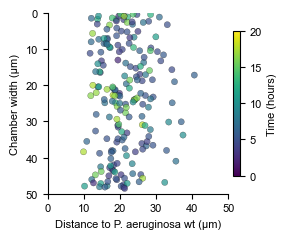

In [6]:
# Load WT colony data
colonies_df = pd.read_csv('../../Figure1/1E_wt/figure_code/1_first_colonies_wt_merged.csv')

print(f"Loaded {len(colonies_df)} colonies")
print(f"Time range: {colonies_df['hours'].min():.2f} - {colonies_df['hours'].max():.2f} hours")

# Configure plotting parameters
pnas_fontsize = 8
fig_width, fig_height = 3, 2.5  # inches
replicate_markers = {'rep1': 'o', 'rep2': 'o', 'rep3': 'o'}

plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial']
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42

# Determine plot range
max_coord = max(colonies_df['x_um'].max(), colonies_df['y_um'].max())
max_coord = np.ceil(max_coord / 10) * 10

# Create figure
fig, ax = plt.subplots(figsize=(fig_width, fig_height))

# Create colormap normalization based on hours
norm = Normalize(vmin=0, vmax=20)  # 0-20 hours
cmap = plt.cm.viridis

# Plot all colonies with time-based coloring
for rep, marker in replicate_markers.items():
    df_rep = colonies_df[colonies_df['replicate'] == rep]
    scatter = ax.scatter(
        df_rep['y_um'], df_rep['x_um'],  # swapped to rotate
        c=df_rep['hours'], cmap=cmap, norm=norm,
        marker=marker, s=20, alpha=0.7,
        edgecolors='k', linewidths=0.2
    )

# Format axes
ax.set_aspect('equal', adjustable='box')
ax.set_xlim(0, max_coord)
ax.set_ylim(0, max_coord)
ax.set_xlabel('Distance to P. aeruginosa wt (µm)', fontsize=pnas_fontsize)
ax.set_ylabel('Chamber width (µm)', fontsize=pnas_fontsize)
ax.tick_params(axis='both', labelsize=pnas_fontsize)
ax.grid(False)
ax.invert_yaxis()  # Flip vertically

# Add colorbar
cbar = plt.colorbar(
    ScalarMappable(norm=norm, cmap=cmap), ax=ax,
    orientation='vertical', pad=0.02, aspect=20, shrink=0.8
)
cbar.set_label('Time (hours)', fontsize=pnas_fontsize)
cbar.ax.tick_params(labelsize=pnas_fontsize)

# Remove top and right spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Save figure
plt.tight_layout()
output_path = 'S6A_wt_spatial_time.pdf'
plt.savefig(output_path, format='pdf', bbox_inches='tight', dpi=300)
print(f"Saved: {output_path}")

plt.show()

## ΔrhlA Mutant Spatial Distribution

Loaded 957 colonies
Time range: 0.00 - 19.75 hours
Saved: S6A_rhlA_spatial_time.pdf


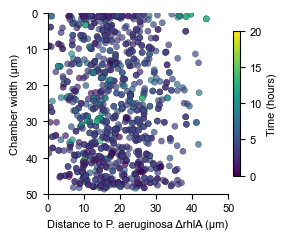

In [7]:
# Load ΔrhlA colony data
colonies_df = pd.read_csv('../2A_mutants/2A_rhlA/figure_code/4_first_colonies_rhlA_merged.csv')

print(f"Loaded {len(colonies_df)} colonies")
print(f"Time range: {colonies_df['hours'].min():.2f} - {colonies_df['hours'].max():.2f} hours")

# Configure plotting parameters
pnas_fontsize = 8
fig_width, fig_height = 3, 2.5  # inches
replicate_markers = {'rep1': 'o', 'rep2': 'o', 'rep3': 'o'}

plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial']
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42

# Determine plot range
max_coord = max(colonies_df['x_um'].max(), colonies_df['y_um'].max())
max_coord = np.ceil(max_coord / 10) * 10

# Create figure
fig, ax = plt.subplots(figsize=(fig_width, fig_height))

# Create colormap normalization based on hours
norm = Normalize(vmin=0, vmax=20)  # 0-20 hours
cmap = plt.cm.viridis

# Plot all colonies with time-based coloring
for rep, marker in replicate_markers.items():
    df_rep = colonies_df[colonies_df['replicate'] == rep]
    scatter = ax.scatter(
        df_rep['y_um'], df_rep['x_um'],  # swapped to rotate
        c=df_rep['hours'], cmap=cmap, norm=norm,
        marker=marker, s=20, alpha=0.7,
        edgecolors='k', linewidths=0.2
    )

# Format axes
ax.set_aspect('equal', adjustable='box')
ax.set_xlim(0, max_coord)
ax.set_ylim(0, max_coord)
ax.set_xlabel('Distance to P. aeruginosa ΔrhlA (µm)', fontsize=pnas_fontsize)
ax.set_ylabel('Chamber width (µm)', fontsize=pnas_fontsize)
ax.tick_params(axis='both', labelsize=pnas_fontsize)
ax.grid(False)
ax.invert_yaxis()  # Flip vertically

# Add colorbar
cbar = plt.colorbar(
    ScalarMappable(norm=norm, cmap=cmap), ax=ax,
    orientation='vertical', pad=0.02, aspect=20, shrink=0.8
)
cbar.set_label('Time (hours)', fontsize=pnas_fontsize)
cbar.ax.tick_params(labelsize=pnas_fontsize)

# Remove top and right spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Save figure
plt.tight_layout()
output_path = 'S6A_rhlA_spatial_time.pdf'
plt.savefig(output_path, format='pdf', bbox_inches='tight', dpi=300)
print(f"Saved: {output_path}")

plt.show()